# NB14 — Diagnostik Kohesi Cluster (Uji Hipotesis Kontaminasi)

**Latar belakang:** NB12 menemukan cluster 120 (hasil final Skenario E, n=1.982)
adalah cluster spurious — 99,8% anggotanya bukan satu identitas (58,4% eksplisit
ditolak manusia saat verifikasi ground truth, 41,4% sudah dianggap noise sejak
baseline 512-dim). LOF tidak menangkapnya karena LOF cuma mengukur *kepadatan
lokal relatif terhadap tetangga* — dan anggota cluster 120 memang padat satu
sama lain (mereka "kolaps" ke wilayah embedding yang mirip akibat degradasi
kualitas), sehingga secara geometris terlihat identik dengan cluster identitas
asli di mata LOF maupun HDBSCAN (yang beroperasi di ruang UMAP 30-dim).

**Hipotesis yang diuji notebook ini:** walau padat di ruang UMAP 30-dim, cluster
spurious seperti ini seharusnya punya **kohesi internal lebih rendah di ruang
ArcFace 512-dim asli** dibanding cluster identitas asli — karena ArcFace secara
eksplisit dilatih memaksimalkan cosine similarity antar foto orang yang SAMA.
Cluster identitas asli = satu sinyal konsisten. Cluster 120 = campuran banyak
sinyal terdegradasi berbeda yang kebetulan berdekatan di ruang reduksi, tapi
tidak benar-benar koheren di ruang aslinya.

Kalau hipotesis ini terbukti, itu jadi dasar usulan **gerbang kualitas di level
cluster** (bukan cuma level titik seperti LOF/GLOSH yang sudah ada) — cluster
hasil HDBSCAN yang lolos densitas tapi gagal uji kohesi 512-dim ditandai utk
ditinjau/dipecah.

**PENTING — notebook ini HANYA MEMBACA output yang sudah ada** (`output_nb01`,
`output_nb10`, `output_nb11`). Tidak ada pipeline yang dijalankan ulang, tidak
ada angka Bab IV yang tersentuh. Output notebook ini masuk folder baru
`output_nb14/`.

## 0. Setup

In [9]:
!pip install scipy -q

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

print('Setup OK.')

Mounted at /content/drive
Setup OK.


## 1. Muat data (baca saja)

Butuh TIGA sumber:
- `output_nb01/embeddings.npy` \u2014 embedding ArcFace 512-dim ASLI (L2-normalized),
  indeks 0..15.247, sebelum LOF/UMAP. Ini yang dipakai uji kohesi (bukan koordinat
  UMAP 30-dim yang dipakai clustering).
- `output_nb11/skenario_e_results.pkl` \u2014 `labels_E` (label final) dan `meta`.
- `output_nb10/skenario_d_results.pkl` \u2014 `idx_inlier` (peta posisi-inlier ke
  indeks global asli di `embeddings.npy`).

In [10]:
BASE       = Path("/content/drive/MyDrive/OTW S.KOM/Embeddings")
NB01_DIR   = BASE / "output_nb01"
NB10_DIR   = BASE / "output_nb10"
NB11_DIR   = BASE / "output_nb11"
OUTPUT_DIR = BASE / "output_nb14"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

embeddings_512 = np.load(NB01_DIR / "embeddings.npy")   # (15248, 512), L2-normalized

with open(NB11_DIR / "skenario_e_results.pkl", "rb") as f:
    results_E = pickle.load(f)
labels_E = results_E["labels_E"]
meta     = results_E["meta"]

with open(NB10_DIR / "skenario_d_results.pkl", "rb") as f:
    results_d = pickle.load(f)
idx_inlier_global = results_d["idx_inlier"]   # posisi-inlier -> indeks global di embeddings_512

assert len(labels_E) == len(idx_inlier_global), "Panjang labels_E dan idx_inlier tidak cocok!"

n_clusters = len(set(labels_E)) - (1 if -1 in labels_E else 0)
print(f"embeddings_512   : {embeddings_512.shape}")
print(f"labels_E         : {len(labels_E):,} titik, {n_clusters} cluster")
print(f"L2-norm check    : min={np.linalg.norm(embeddings_512, axis=1).min():.4f}  "
      f"max={np.linalg.norm(embeddings_512, axis=1).max():.4f}")

embeddings_512   : (15248, 512)
labels_E         : 14,790 titik, 139 cluster
L2-norm check    : min=1.0000  max=1.0000


## 2. Fungsi kohesi \u2014 cosine similarity ke centroid, di ruang 512-dim

Karena embedding sudah L2-normalized, cosine similarity antar dua embedding =
dot product-nya langsung (tidak perlu bagi norma). Kohesi tiap titik didefinisikan
sebagai similarity-nya ke centroid cluster (centroid dinormalisasi ulang jadi unit
vector). Metrik ini standar & murah secara komputasi (O(n) per cluster, bukan
O(n\u00b2)) \u2014 cukup cepat dijalankan ke seluruh 139 cluster di Bagian 5.

In [11]:
def kohesi_cluster(cluster_id):
    """Return array cosine-similarity tiap anggota cluster ke centroid-nya (512-dim)."""
    idx_local = np.where(labels_E == cluster_id)[0]
    idx_global = idx_inlier_global[idx_local]
    X = embeddings_512[idx_global]                 # (n, 512), sudah L2-normalized

    centroid = X.mean(axis=0)
    centroid = centroid / np.linalg.norm(centroid)  # normalisasi ulang jadi unit vector

    sim_to_centroid = X @ centroid                  # (n,) cosine similarity per titik
    return sim_to_centroid

print("Fungsi siap. Uji cepat pada cluster 120:")
tes = kohesi_cluster(120)
print(f"  n={len(tes)}  mean={tes.mean():.4f}  median={np.median(tes):.4f}  std={tes.std():.4f}")

Fungsi siap. Uji cepat pada cluster 120:
  n=1982  mean=0.5266  median=0.5369  std=0.1727


## 3. Bandingkan kohesi \u2014 cluster 120 vs 7 cluster besar lain

Sengaja pakai cluster besar yang SAMA seperti diagnostik NB12 (top-8 by size)
supaya hasilnya bisa langsung disandingkan dengan temuan sebelumnya (7 di
antaranya sudah terverifikasi 1 identitas via ground truth, cluster 120
terverifikasi kontaminasi 3 identitas).

In [12]:
cluster_sizes = Counter(labels_E[labels_E >= 0].tolist())
sizes_sorted  = sorted(cluster_sizes.items(), key=lambda x: -x[1])
N_TOP = 8
top_clusters = [cid for cid, _ in sizes_sorted[:N_TOP]]

hasil_kohesi = {}
rows = []
for cid in top_clusters:
    sim = kohesi_cluster(cid)
    hasil_kohesi[cid] = sim
    rows.append(dict(cluster=cid, n=len(sim), mean_kohesi=sim.mean(),
                      median_kohesi=np.median(sim), std_kohesi=sim.std(),
                      min_kohesi=sim.min()))

df_kohesi = pd.DataFrame(rows).sort_values("mean_kohesi")
print(df_kohesi.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

df_kohesi.to_csv(OUTPUT_DIR / "kohesi_top8_cluster.csv", index=False)

 cluster    n  mean_kohesi  median_kohesi  std_kohesi  min_kohesi
     120 1982       0.5266         0.5369      0.1727      0.0772
      48  255       0.6558         0.7115      0.1561      0.2315
      47  242       0.6902         0.7297      0.1379      0.2487
      39  253       0.6992         0.7269      0.1343      0.2763
      26  247       0.7025         0.7533      0.1422      0.1922
      54  284       0.7066         0.7604      0.1391      0.2899
      27  273       0.7184         0.7580      0.1232      0.3192
      58  236       0.7870         0.8324      0.1245      0.1761


## 4. Visualisasi \u2014 distribusi kohesi per cluster

/tmp/ipykernel_685/441095005.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data_plot, labels=labels_plot, patch_artist=True, showfliers=False)


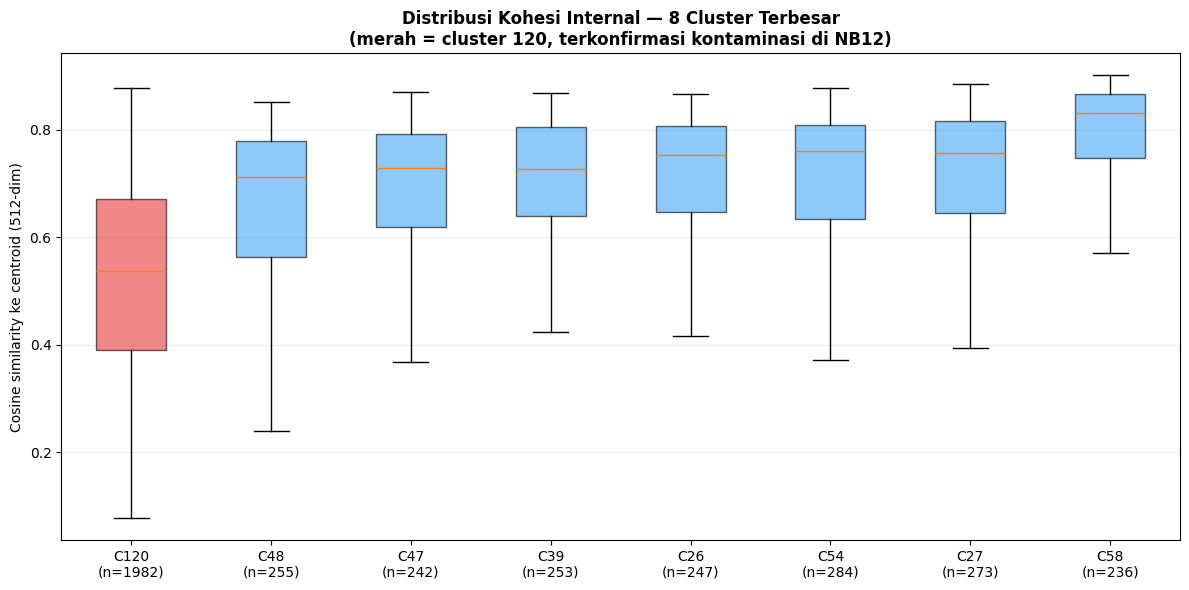

In [13]:
order_plot = df_kohesi["cluster"].tolist()   # urut dari kohesi terendah
data_plot  = [hasil_kohesi[cid] for cid in order_plot]
labels_plot = [f"C{cid}\n(n={len(hasil_kohesi[cid])})" for cid in order_plot]
colors_plot = ['#E53935' if cid == 120 else '#42A5F5' for cid in order_plot]

fig, ax = plt.subplots(figsize=(12, 6))
bplot = ax.boxplot(data_plot, labels=labels_plot, patch_artist=True, showfliers=False)
for patch, c in zip(bplot['boxes'], colors_plot):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)

ax.set_ylabel("Cosine similarity ke centroid (512-dim)")
ax.set_title("Distribusi Kohesi Internal \u2014 8 Cluster Terbesar\n"
             "(merah = cluster 120, terkonfirmasi kontaminasi di NB12)",
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribusi_kohesi_top8.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Uji statistik \u2014 apakah beda kohesi ini signifikan?

Mann-Whitney U (non-parametrik, tidak asumsi distribusi normal \u2014 cocok utk
similarity yang terbatas di [-1,1] dan kemungkinan skewed): bandingkan seluruh
nilai kohesi per-titik cluster 120 vs GABUNGAN seluruh nilai kohesi per-titik
7 cluster "bersih" lainnya.

In [14]:
sim_c120 = hasil_kohesi[120]
sim_lain = np.concatenate([hasil_kohesi[cid] for cid in top_clusters if cid != 120])

u_stat, p_value = stats.mannwhitneyu(sim_c120, sim_lain, alternative='less')

print(f"Cluster 120        : n={len(sim_c120)}  mean={sim_c120.mean():.4f}  median={np.median(sim_c120):.4f}")
print(f"7 cluster lain (gabung): n={len(sim_lain)}  mean={sim_lain.mean():.4f}  median={np.median(sim_lain):.4f}")
print()
print(f"Mann-Whitney U = {u_stat:.1f}, p-value (H1: cluster 120 LEBIH RENDAH) = {p_value:.2e}")

if p_value < 0.001:
    print("\n\u2713 SANGAT SIGNIFIKAN (p < 0,001): kohesi cluster 120 terbukti lebih rendah "
          "secara statistik, bukan kebetulan sampling.")
elif p_value < 0.05:
    print("\n\u2713 signifikan (p < 0,05).")
else:
    print("\n\u26a0 tidak signifikan pada \u03b1=0,05 \u2014 hipotesis TIDAK terbukti dgn data ini.")

Cluster 120        : n=1982  mean=0.5266  median=0.5369
7 cluster lain (gabung): n=1790  mean=0.7079  median=0.7518

Mann-Whitney U = 713901.0, p-value (H1: cluster 120 LEBIH RENDAH) = 2.38e-221

✓ SANGAT SIGNIFIKAN (p < 0,001): kohesi cluster 120 terbukti lebih rendah secara statistik, bukan kebetulan sampling.


## 6. Generalisasi \u2014 di mana peringkat cluster 120 di antara SELURUH 139 cluster?

Sampel 8 cluster kecil, rawan kebetulan. Bagian ini menghitung kohesi rata-rata
utk SEMUA cluster (bukan cuma top-8) \u2014 murah karena metrik centroid O(n) per
cluster \u2014 lalu melihat persis di persentil berapa cluster 120 berada.

Total cluster dianalisis: 139

Peringkat cluster 120 berdasar mean_kohesi (0 = paling tidak koheren):
 cluster    n  mean_kohesi  persentil
     120 1982       0.5266     4.3478

10 cluster dengan kohesi TERENDAH di seluruh dataset:
 cluster    n  mean_kohesi  persentil
     135   37       0.4212     0.0000
     136   84       0.4493     0.7246
     138   18       0.4881     1.4493
     119  138       0.4948     2.1739
     122  110       0.5140     2.8986
     118   45       0.5180     3.6232
     120 1982       0.5266     4.3478
     117   24       0.5366     5.0725
     134   35       0.6272     5.7971
     121   21       0.6274     6.5217


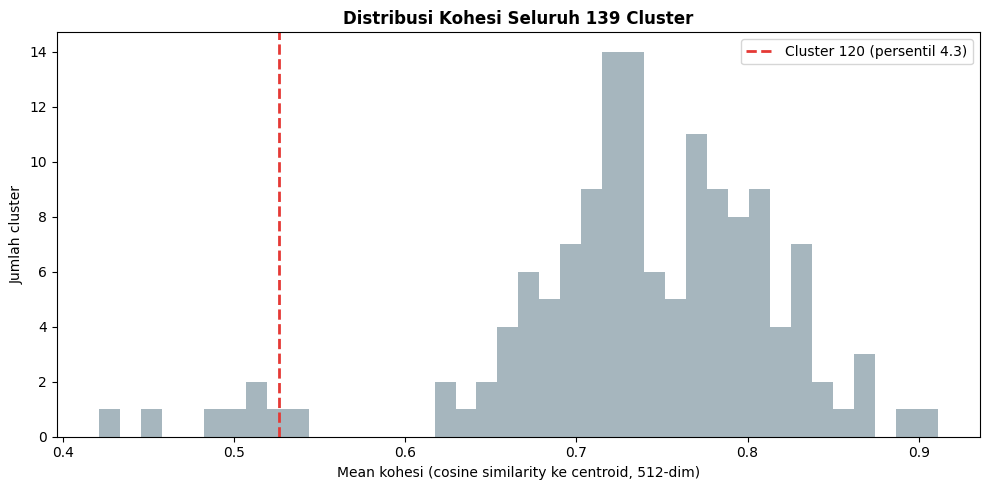

In [15]:
semua_cluster_id = sorted(cluster_sizes.keys())
rows_full = []
for cid in semua_cluster_id:
    sim = kohesi_cluster(cid)
    rows_full.append(dict(cluster=cid, n=len(sim), mean_kohesi=sim.mean()))

df_full = pd.DataFrame(rows_full).sort_values("mean_kohesi").reset_index(drop=True)
df_full["persentil"] = df_full.index / (len(df_full) - 1) * 100  # 0 = kohesi terendah

peringkat_120 = df_full[df_full["cluster"] == 120]
print(f"Total cluster dianalisis: {len(df_full)}")
print(f"\nPeringkat cluster 120 berdasar mean_kohesi (0 = paling tidak koheren):")
print(peringkat_120.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print(f"\n10 cluster dengan kohesi TERENDAH di seluruh dataset:")
print(df_full.head(10).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

df_full.to_csv(OUTPUT_DIR / "kohesi_semua_cluster.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_full["mean_kohesi"], bins=40, color='#90A4AE', alpha=0.8)
ax.axvline(peringkat_120["mean_kohesi"].values[0], color='#E53935', linestyle='--',
           linewidth=2, label=f"Cluster 120 (persentil {peringkat_120['persentil'].values[0]:.1f})")
ax.set_xlabel("Mean kohesi (cosine similarity ke centroid, 512-dim)")
ax.set_ylabel("Jumlah cluster")
ax.set_title(f"Distribusi Kohesi Seluruh {len(df_full)} Cluster", fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribusi_kohesi_semua_cluster.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Kesimpulan

Isi bagian ini setelah melihat hasil Bagian 5 dan 6:

- Kalau p-value Bagian 5 sangat kecil DAN cluster 120 berada di persentil
  terendah (mendekati 0) pada Bagian 6 \u2192 hipotesis kohesi **terbukti kuat**.
  Layak diusulkan sebagai mekanisme gerbang kualitas level-cluster tambahan,
  dengan ambang yang bisa dikalibrasi dari `df_full` (mis. persentil ke-5
  terendah ditandai utk review manual).
- Kalau cluster 120 TIDAK berada di ekor terendah di Bagian 6 (ada banyak
  cluster lain dengan kohesi serendah/lebih rendah, padahal tidak terbukti
  kontaminasi di NB12) \u2192 kohesi 512-dim SAJA tidak cukup jadi pembeda tunggal;
  kombinasikan dengan sinyal lain (det_score, ukuran cluster, ground truth) \u2014
  catat sebagai keterbatasan pendekatan ini di skripsi, jangan dipaksakan.

**Baik hasilnya positif maupun negatif, keduanya adalah temuan yang sah untuk
dilaporkan** \u2014 tujuan notebook ini menguji hipotesis dengan data, bukan
mengonfirmasi asumsi.

In [16]:
print("=" * 60)
print("  RINGKASAN NB14 \u2014 DIAGNOSTIK KOHESI CLUSTER")
print("=" * 60)
print(f"  Cluster diuji (top-8)     : {top_clusters}")
print(f"  Mann-Whitney p-value      : {p_value:.2e}")
print(f"  Persentil kohesi cluster 120 (dari {len(df_full)} cluster): "
      f"{peringkat_120['persentil'].values[0]:.1f}")
print(f"  Output disimpan ke        : {OUTPUT_DIR}")
print("=" * 60)

  RINGKASAN NB14 — DIAGNOSTIK KOHESI CLUSTER
  Cluster diuji (top-8)     : [120, 54, 27, 48, 39, 26, 47, 58]
  Mann-Whitney p-value      : 2.38e-221
  Persentil kohesi cluster 120 (dari 139 cluster): 4.3
  Output disimpan ke        : /content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb14


## 8. Cross-check ground truth \u2014 6+ cluster berkohesi LEBIH RENDAH dari 120

Temuan Bagian 6: ada 6 cluster (135, 136, 138, 119, 122, 118) dengan kohesi
lebih rendah dari cluster 120, tapi belum pernah diverifikasi ground truth
karena ukurannya kecil (tidak masuk "top-8 by size" di NB12). Dua kemungkinan:

- **Kalau ikut kontaminasi (>1 identitas)** \u2192 kohesi 512-dim adalah detektor
  yang LEBIH BAIK dari pendekatan "cek cluster terbesar" \u2014 bisa menangkap
  kontaminasi di cluster kecil yang selama ini lolos radar.
- **Kalau ternyata 1 identitas sah** \u2192 kohesi rendah tidak otomatis berarti
  kontaminasi utk cluster kecil (variansi natural lebih tinggi krn sampel
  sedikit) \u2014 ambang kohesi perlu dikalibrasi ulang per ukuran cluster.

Pakai metode identik dgn `analisis_kontaminasi` di NB12 (status ok/merge/
discard/noise/pending dari `face_labels_verified.csv` + `identity_id`).

In [17]:
import csv as _csv

gt_path = BASE / "output_labeling" / "face_labels_verified.csv"

if not gt_path.exists():
    print(f"File ground truth tidak ditemukan di {gt_path} \u2014 cek path.")
else:
    gid_to_identity = {}
    status_by_gid = {}
    with open(gt_path, newline='', encoding='utf-8') as f:
        for row in _csv.DictReader(f):
            gid = int(row['global_index'])
            gid_to_identity[gid] = row['identity_id']
            status_by_gid[gid] = row['status']

    def analisis_kontaminasi(cluster_id):
        idx_local = np.where(labels_E == cluster_id)[0]
        status_counts = Counter()
        identity_counts = Counter()
        for li in idx_local:
            gidx = int(idx_inlier_global[li])
            st = status_by_gid.get(gidx, 'TIDAK_ADA_DI_CSV')
            status_counts[st] += 1
            ident = gid_to_identity.get(gidx)
            if ident is not None and ident != '-1':
                identity_counts[ident] += 1
        n = len(idx_local)
        n_ok = status_counts.get('ok', 0) + status_counts.get('merge', 0)
        n_bad = status_counts.get('discard', 0) + status_counts.get('noise', 0)
        return dict(cluster=cluster_id, n=n, n_ok=n_ok, n_bad=n_bad,
                    pct_bad=(n_bad / n * 100 if n else 0),
                    n_identitas=len(identity_counts))

    def klasifikasi(r):
        """Klasifikasi lebih lengkap dari cek 'n_identitas > 1' saja -- juga
        menangkap kasus n_ok sangat rendah/nol meski n_identitas cuma 0/1
        (ditemukan di 5 cluster: 135/136/138/118/117 punya n_ok=0 persis,
        yang tidak tertangkap kriteria lama)."""
        if r['n'] == 0:
            return 'n=0'
        if r['n_identitas'] > 1:
            return 'KONTAMINASI (multi-identitas)'
        if r['n_ok'] == 0:
            return 'SANGAT MENCURIGAKAN (nol identitas terverifikasi)'
        if r['n_ok'] / r['n'] < 0.10:
            return 'MENCURIGAKAN (identitas terverifikasi <10%)'
        return 'bersih'

    kandidat = df_full.head(10)["cluster"].tolist()   # 10 cluster kohesi terendah (termasuk 120)
    hasil_cek = [analisis_kontaminasi(cid) for cid in kandidat]
    for r in hasil_cek:
        r['klasifikasi'] = klasifikasi(r)

    print(f"{'cluster':>8} {'n':>6} {'n_ok':>6} {'n_bad':>6} {'%bad':>7} {'#identitas':>11}  klasifikasi")
    for r in hasil_cek:
        print(f"{r['cluster']:>8} {r['n']:>6} {r['n_ok']:>6} {r['n_bad']:>6} {r['pct_bad']:>6.1f}% "
              f"{r['n_identitas']:>11}  {r['klasifikasi']}")

    bersih = [r['cluster'] for r in hasil_cek if r['klasifikasi'] == 'bersih']
    bermasalah = [r['cluster'] for r in hasil_cek if r['klasifikasi'] != 'bersih' and r['cluster'] != 120]
    print(f"\nCluster BERMASALAH (di luar 120, klasifikasi apa pun selain bersih): {bermasalah}")
    print(f"Cluster BERSIH (di luar 120): {bersih}")
    print(f"\n-> Dari {len(kandidat)-1} cluster tambahan yg dicek (di luar 120), "
          f"{len(bermasalah)} menunjukkan bukti kontaminasi, {len(bersih)} bersih.")
    if len(bermasalah) >= len(kandidat) - 1 - len(bersih) and len(bermasalah) > 1:
        print("-> Kohesi 512-dim TERBUKTI mendeteksi kontaminasi jauh lebih luas dari yg")
        print("   ditemukan pendekatan size-based NB12 -- penguatan kuat utk usulan gerbang")
        print("   kualitas level-cluster berbasis kohesi, dgn kriteria: n_identitas>1 ATAU")
        print("   rasio n_ok/n < 10% (bukan cuma n_identitas>1 saja).")

 cluster      n   n_ok  n_bad    %bad  #identitas  klasifikasi
     135     37      0     37  100.0%           0  SANGAT MENCURIGAKAN (nol identitas terverifikasi)
     136     84      0     84  100.0%           0  SANGAT MENCURIGAKAN (nol identitas terverifikasi)
     138     18      0     18  100.0%           0  SANGAT MENCURIGAKAN (nol identitas terverifikasi)
     119    138      5    133   96.4%           3  KONTAMINASI (multi-identitas)
     122    110      2    108   98.2%           1  MENCURIGAKAN (identitas terverifikasi <10%)
     118     45      0     45  100.0%           0  SANGAT MENCURIGAKAN (nol identitas terverifikasi)
     120   1982      4   1978   99.8%           3  KONTAMINASI (multi-identitas)
     117     24      0     24  100.0%           0  SANGAT MENCURIGAKAN (nol identitas terverifikasi)
     134     35     21     14   40.0%           1  bersih
     121     21      5     16   76.2%           1  bersih

Cluster BERMASALAH (di luar 120, klasifikasi apa pun selai